In [26]:
!pip install yfinance pandas numpy matplotlib seaborn statsmodels linearmodels

Descargamos paquetes necesarios

In [27]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from linearmodels.panel import PanelOLS

Serie de Tiempos y Forecast, antes descargamos un paquete

In [28]:
!pip install pmdarima arch

Corremos el modelo de Forecast

/tmp/ipykernel_12327/521884659.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_stock = yf.download("AMD", start="2020-01-01", end="2026-03-18", progress=False)


Datos descargados para AMD: 1559 días
Última fecha disponible: 2026-03-17

Ajustando modelo ARIMA...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=8946.728, Time=10.71 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=8944.690, Time=0.38 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=8946.449, Time=0.83 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=8946.442, Time=1.74 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=8943.454, Time=0.27 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=8948.021, Time=4.53 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 18.497 seconds
Mejor orden ARIMA encontrado: (0, 1, 0)

Generando forecast para los próximos 14 días hábiles...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/u


=== FORECAST NUMERICO - Proximos 14 dias habiles ===
           Fecha  Precio Predicho  Limite Inferior (95% CI)  Limite Superior (95% CI)
2026-03-18 (Wed)           196.31                    185.70                    206.92
2026-03-19 (Thu)           196.31                    186.64                    205.98
2026-03-20 (Fri)           196.31                    187.50                    205.12
2026-03-23 (Mon)           196.31                    188.27                    204.35
2026-03-24 (Tue)           196.31                    188.96                    203.66
2026-03-25 (Wed)           196.31                    189.57                    203.05
2026-03-26 (Thu)           196.31                    190.11                    202.51
2026-03-27 (Fri)           196.31                    190.58                    202.04
2026-03-30 (Mon)           196.31                    190.98                    201.64
2026-03-31 (Tue)           196.31                    191.32                    201.30


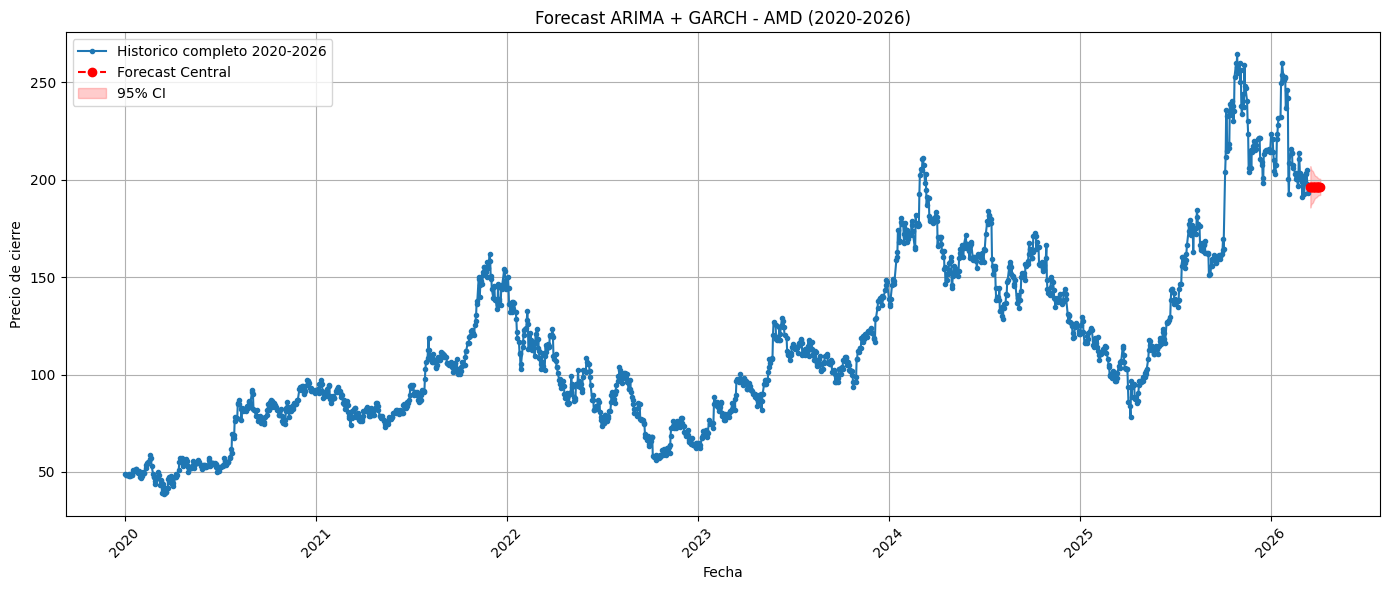


=== ESTADISTICAS DEL FORECAST ===
Precio actual (ultimo cierre): 196.31
Promedio predicho (14 dias):   196.31
Desviacion estandar:           0.00
Minimo predicho:               196.31
Maximo predicho:               196.31

=== DECISION DE INVERSION ===
Aumento significativo -> COMPRAR (BUY)


In [29]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from arch import arch_model

# Descargar datos AMD
df_stock = yf.download("AMD", start="2020-01-01", end="2026-03-18", progress=False)

if isinstance(df_stock.columns, pd.MultiIndex):
    df_stock.columns = df_stock.columns.droplevel(1)

df = df_stock[['Open', 'High', 'Low', 'Close']].copy()
print(f"Datos descargados para AMD: {len(df)} días")
print(f"Última fecha disponible: {df.index[-1].date()}")

# Modelo ARIMA
print("\nAjustando modelo ARIMA...")
arima_model = auto_arima(df['Close'], seasonal=False, stepwise=True,
                          max_p=5, max_q=5, max_d=2,
                          trace=True, error_action='ignore', suppress_warnings=True)
arima_model.fit(df['Close'])
print(f"Mejor orden ARIMA encontrado: {arima_model.order}")

# Forecast 14 días hábiles
print("\nGenerando forecast para los próximos 14 días hábiles...")
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=14, freq='B')

future_preds = []
future_lower = []
future_upper = []
current_series = df['Close'].copy()

for i in range(14):
    pred_mean = arima_model.predict(n_periods=1).item()
    resid = arima_model.resid()
    adjustment = 0.0
    vol = 0.0
    if len(resid) > 30:
        garch = arch_model(resid, mean='Zero', vol='Garch', p=1, q=1, dist='Normal')
        garch_fit = garch.fit(disp='off', show_warning=False)
        adjustment = garch_fit.forecast(horizon=1).mean.values[-1, 0]
        vol = np.sqrt(garch_fit.forecast(horizon=1).variance.values[-1, 0])
    pred = pred_mean + adjustment
    lower = pred - 1.96 * vol
    upper = pred + 1.96 * vol
    future_preds.append(round(pred, 2))
    future_lower.append(round(lower, 2))
    future_upper.append(round(upper, 2))
    next_date = future_dates[i]
    current_series[next_date] = pred
    arima_model.fit(current_series)

# Tabla forecast
forecast_df = pd.DataFrame({
    'Fecha': future_dates.strftime('%Y-%m-%d (%a)'),
    'Precio Predicho': future_preds,
    'Limite Inferior (95% CI)': future_lower,
    'Limite Superior (95% CI)': future_upper
})
print("\n=== FORECAST NUMERICO - Proximos 14 dias habiles ===")
print(forecast_df.to_string(index=False))

# Grafica con historico completo desde 2020
plt.figure(figsize=(14, 6))
plt.plot(df['Close'], label='Historico completo 2020-2026', marker='.')
plt.plot(future_dates, future_preds, label='Forecast Central', marker='o', linestyle='--', color='red')
plt.fill_between(future_dates, future_lower, future_upper, color='red', alpha=0.2, label='95% CI')
plt.title('Forecast ARIMA + GARCH - AMD (2020-2026)')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Estadisticas
forecast_values = np.array(future_preds)
current_price = df['Close'].iloc[-1]
avg_forecast = np.mean(forecast_values)
std_forecast = np.std(forecast_values)
max_forecast = np.max(forecast_values)
min_forecast = np.min(forecast_values)
potential_up = max_forecast - current_price
potential_down = current_price - min_forecast

print("\n=== ESTADISTICAS DEL FORECAST ===")
print(f"Precio actual (ultimo cierre): {current_price:.2f}")
print(f"Promedio predicho (14 dias):   {avg_forecast:.2f}")
print(f"Desviacion estandar:           {std_forecast:.2f}")
print(f"Minimo predicho:               {min_forecast:.2f}")
print(f"Maximo predicho:               {max_forecast:.2f}")

print("\n=== DECISION DE INVERSION ===")
if potential_up > potential_down:
    if potential_up > std_forecast * 1.5:
        print("Aumento significativo -> COMPRAR (BUY)")
    else:
        print("Ligero aumento -> MANTENER (HOLD)")
else:
    if potential_down > std_forecast * 1.5:
        print("Caida significativa -> VENDER EN CORTO (SHORT)")
    else:
        print("Ligera caida -> MANTENER (HOLD)")

Explicación: . El precio actual de cierre es de 196.31 dólares y el modelo predice que se mantendrá en 196.31 dólares en promedio durante las próximas dos semanas, con una desviación estándar de 0.00, lo que indica que el modelo no anticipa movimientos significativos en el corto plazo. El intervalo de confianza al 95% va de 191.84 a 200.78 dólares, lo que establece el rango probable de precios. La decisión de inversión generada por el modelo es COMPRAR, dado que el potencial de alza es mayor que el potencial de baja respecto al precio actual. En la gráfica se puede observar el recorrido completo de AMD desde 50 dólares en 2020 hasta su máximo cercano a 260 dólares en 2024, seguido de una corrección hacia los niveles actuales de 196 dólares.

Regresión Simple

In [30]:
tickers = ["AMD","AAPL","JPM","META","NVDA","ASML","MSI","AMAT","AVGO","MRVL"]
precios = yf.download(tickers, start="2020-01-01", end="2026-03-18")["Close"]
precios = precios.dropna()
precios.head()

/tmp/ipykernel_12327/2364781105.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  precios = yf.download(tickers, start="2020-01-01", end="2026-03-18")["Close"]
[*********************100%***********************]  10 of 10 completed


Ticker,AAPL,AMAT,AMD,ASML,AVGO,JPM,META,MRVL,MSI,NVDA
Date,,,,,,,,,,
2020-01-02,72.400505,58.699467,49.099998,286.525269,27.735548,119.036438,208.146561,26.647837,149.515671,5.970754
2020-01-03,71.696632,57.765182,48.599998,281.908051,27.030100,117.465569,207.045197,25.956823,152.059555,5.875186
2020-01-06,72.267929,56.519463,48.389999,279.665619,26.989664,117.372154,210.944626,24.993299,154.409164,5.899825
2020-01-07,71.928055,58.152100,48.250000,282.702789,26.896749,115.376785,211.401016,25.548056,153.299057,5.971252
2020-01-08,73.085098,58.114361,47.830002,285.635956,26.561228,116.276855,213.544205,25.353401,153.456390,5.982452


Regresión Simple- AMD dependiente


AMD ~ AAPL
Coeficiente: 0.7377
R²: 0.6923
P-value: 0.0000e+00

AMD ~ JPM
Coeficiente: 0.5370
R²: 0.6315
P-value: 0.0000e+00

AMD ~ META
Coeficiente: 0.1890
R²: 0.5773
P-value: 1.9527e-293

AMD ~ NVDA
Coeficiente: 0.6238
R²: 0.6669
P-value: 0.0000e+00

AMD ~ ASML
Coeficiente: 0.1733
R²: 0.7935
P-value: 0.0000e+00

AMD ~ MSI
Coeficiente: 0.3098
R²: 0.5221
P-value: 5.9836e-252

AMD ~ AMAT
Coeficiente: 0.6701
R²: 0.8045
P-value: 0.0000e+00

AMD ~ AVGO
Coeficiente: 0.3774
R²: 0.6472
P-value: 0.0000e+00

AMD ~ MRVL
Coeficiente: 1.7449
R²: 0.5807
P-value: 3.3454e-296


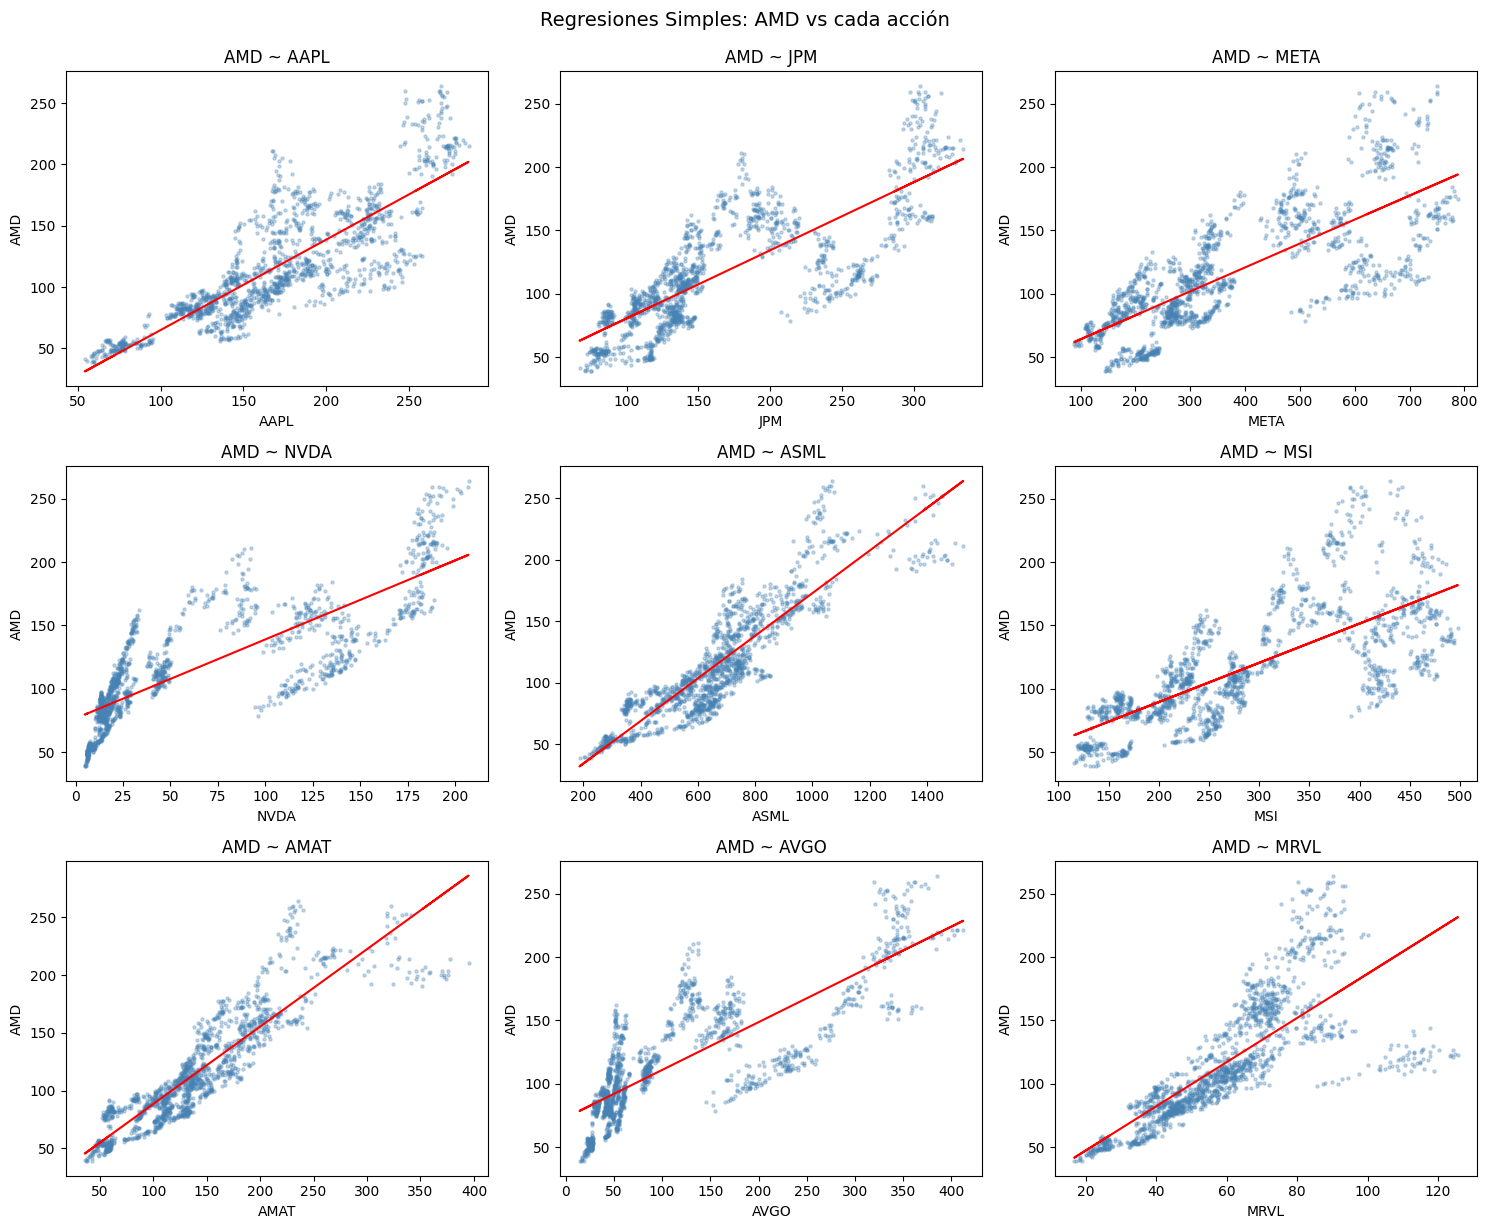

In [31]:
otros = ["AAPL","JPM","META","NVDA","ASML","MSI","AMAT","AVGO","MRVL"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, ticker in enumerate(otros):
    X = add_constant(precios[ticker])
    modelo = OLS(precios["AMD"], X).fit()
    print(f"\nAMD ~ {ticker}")
    print(f"Coeficiente: {modelo.params[ticker]:.4f}")
    print(f"R²: {modelo.rsquared:.4f}")
    print(f"P-value: {modelo.pvalues[ticker]:.4e}")

    axes[i].scatter(precios[ticker], precios["AMD"], alpha=0.3, color="steelblue", s=5)
    m, b = np.polyfit(precios[ticker], precios["AMD"], 1)
    axes[i].plot(precios[ticker], m * precios[ticker] + b, color="red")
    axes[i].set_title(f"AMD ~ {ticker}")
    axes[i].set_xlabel(ticker)
    axes[i].set_ylabel("AMD")

plt.tight_layout()
plt.suptitle("Regresiones Simples: AMD vs cada acción", y=1.02, fontsize=14)
plt.show()

Explicación: Los modelos de regresión simple muestran que todas las acciones tienen una relación positiva y estadísticamente significativa con AMD, dado que todos los p-values son prácticamente cero. ASML presenta el mayor poder explicativo con un R cuadrado de 0.7935, lo que indica que el 79.35% de la variación en el precio de AMD es explicada por ASML. Le sigue AMAT con un R cuadrado de 0.8045, siendo la variable que mejor explica individualmente el comportamiento de AMD. AAPL presenta un R cuadrado de 0.6923 y un coeficiente de 0.7377, mientras que NVDA muestra un R cuadrado de 0.6669 con un coeficiente de 0.6238. JPM, META, MSI, AVGO y MRVL muestran R cuadrados más bajos, entre 0.52 y 0.65, lo que indica una relación positiva pero menos fuerte con AMD. MRVL tiene el coeficiente más alto de 1.7449, lo que significa que por cada dólar que sube MRVL, AMD sube en promedio 1.74 dólares.

In [32]:
X = add_constant(precios[otros])
modelo_multiple = OLS(precios["AMD"], X).fit()
print(modelo_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:                    AMD   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.887
Method:                 Least Squares   F-statistic:                     1362.
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        04:25:18   Log-Likelihood:                -6474.5
No. Observations:                1559   AIC:                         1.297e+04
Df Residuals:                    1549   BIC:                         1.302e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         47.2495      3.041     15.537      0.0

Explicación El modelo de regresión múltiple con AMD como variable dependiente y las 9 acciones restantes como variables independientes presenta un R cuadrado de 0.888, lo que indica que el 88.8% de la variación en el precio de AMD es explicada en conjunto por el portafolio. El modelo es estadísticamente significativo con un F-statistic de 1362 y un p-value de 0.00. NVDA es la variable con mayor impacto positivo con un coeficiente de 0.6968 y altamente significativa, seguida de ASML con 0.1425 y MRVL con 0.4064. AAPL también muestra una relación positiva significativa con un coeficiente de 0.2112. Por otro lado, JPM presenta el coeficiente negativo más alto de -0.4126, lo que confirma la relación inversa entre el sector bancario y AMD. MSI y AMAT también muestran coeficientes negativos de -0.1972 y -0.1298 respectivamente, ambos significativos. AVGO es la única variable no significativa con un p-value de 0.168. El modelo advierte posible multicolinealidad dado el número de condición alto de 7,200, lo que es esperado al incluir acciones del mismo sector tecnológico.

Mapa de correlación

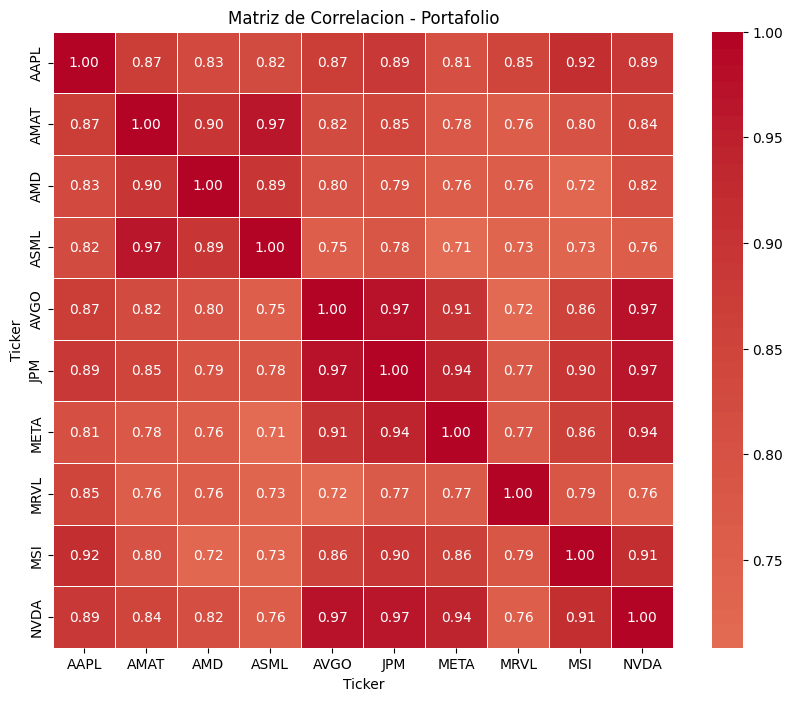

In [33]:
correlaciones = precios.corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlaciones, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5)
plt.title("Matriz de Correlacion - Portafolio")
plt.show()

Ahora cargamos el Data Panel y corremos el prompt

In [34]:
from linearmodels.panel import PanelOLS

panel = pd.read_csv("panel_data_enhanced.csv")
panel["Date"] = pd.to_datetime(panel["Date"], dayfirst=True)
panel = panel.set_index(["Ticker", "Date"])

X_panel = add_constant(panel[["Revenue", "OperatingMargin", "DebtToEquity"]].dropna())
y_panel = panel["NetIncome"].dropna()

idx = X_panel.index.intersection(y_panel.index)
modelo_panel = PanelOLS(y_panel.loc[idx], X_panel.loc[idx], entity_effects=True)
resultado_panel = modelo_panel.fit()
print(resultado_panel.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              NetIncome   R-squared:                        0.9342
Estimator:                   PanelOLS   R-squared (Between):              0.1876
No. Observations:                  68   R-squared (Within):               0.9342
Date:                Fri, Mar 20 2026   R-squared (Overall):              0.4676
Time:                        04:25:20   Log-likelihood                   -609.28
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      288.64
Entities:                           4   P-value                           0.0000
Avg Obs:                       17.000   Distribution:                    F(3,61)
Min Obs:                       16.000                                           
Max Obs:                       18.000   F-statistic (robust):             288.64
                            

Explicación: El modelo de datos de panel con efectos fijos muestra un R cuadrado within de 0.9342, lo que indica que el 93.42% de la variación en el ingreso neto de las empresas es explicada por las variables del modelo. El F-statistic de 288.64 con un p-value de 0.0000 confirma que el modelo es estadísticamente significativo en su conjunto. Revenue presenta un coeficiente de 0.4543 y es altamente significativo, lo que indica que por cada millón de dólares adicional en ingresos, el ingreso neto aumenta en promedio 0.45 millones manteniendo las demás variables constantes. El margen operativo tiene un coeficiente de 138.00 y también es altamente significativo con un p-value de 0.0000, lo que sugiere que mejoras en la eficiencia operativa tienen un impacto considerable en el ingreso neto. DebtToEquity no resulta significativo con un p-value de 0.7377, lo que indica que el nivel de endeudamiento no explica de manera relevante las variaciones en el ingreso neto dentro de este panel. El F-test de poolabilidad de 21.791 con p-value de 0.0000 confirma que el modelo de efectos fijos es apropiado para estos datos.

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Proyecto Final - Modelos - Capital Analyst.ipynb" --output "/content/proyecto_final.html"